In [22]:
# Import the SOAP utilities, plotting tools, and local spectrum helper functions.
import SOAP
from SOAP import PHOENIX
import matplotlib.pyplot as plt
import numpy as np
from ldtk import LDPSetCreator, BoxcarFilter
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from create_spectrum_SOAP import create_spectrum_soap, create_spectrum_phoenix
from pathlib import Path
from create_ccf_ARVE import create_arve_ccf
from spectrum_rv_utils import apply_rv_shift_on_original_grid, shift_spectrum_csv


In [23]:
# Define one workflow function that can compute PHOENIX and/or SOAP spectra,
# save the selected outputs as .npz files, and return everything in a results dictionary.
def run_spectrum_workflow(load_phoenix=True, load_soap=True, save_dir="saved_spectra"):
    teff = 5778
    teff_sig = 10
    logg = 4.4374
    logg_sig = 0.001
    feh = 0.00
    feh_sig = 0.01
    wave_min = 3800.0
    wave_max = 7800.0
    wavelength_mode = "vacuum"
    R = 140000
    prot = 25.67
    radius = 1.0
    mass = 1.0
    u1 = 0.29
    u2 = 0.34
    diffrotB = 0.163
    diffrotC = 0.121
    cb1 = 0.0
    psi = [0]
    incl = 90.0

    save_path = Path(save_dir)
    save_path.mkdir(parents=True, exist_ok=True)

    results = {
        "spec_phoenix": None,
        "wave_phoenix": None,
        "flux_phoenix": None,
        "soap_result": None,
        "wave_soap": None,
        "flux_soap": None,
        "ccf_flux_soap": None,
        "rv_ccf_soap": None,
        "sim_soap": None,
        "output_soap": None,
        "spectrum_soap": None,
    }

    if load_phoenix:
        spec_phoenix, wave_phoenix, flux_phoenix = create_spectrum_phoenix(
            teff=teff,
            logg=logg,
            z=feh,
            wave_min=wave_min,
            wave_max=wave_max,
            wavelength_mode=wavelength_mode,
            r=R,
            normalize_max=True,
        )

        np.savez(
            save_path / "phoenix_output.npz",
            spec_phoenix_wave=np.asarray(spec_phoenix.wave),
            spec_phoenix_flux=np.asarray(spec_phoenix.flux),
            wave_phoenix=np.asarray(wave_phoenix),
            flux_phoenix=np.asarray(flux_phoenix),
        )

        results["spec_phoenix"] = spec_phoenix
        results["wave_phoenix"] = wave_phoenix
        results["flux_phoenix"] = flux_phoenix

    if load_soap:
        soap_result = create_spectrum_soap(
            teff=teff,
            logg=logg,
            z=feh,
            wave_min=wave_min,
            wave_max=wave_max,
            wavelength_mode=wavelength_mode,
            r=R,
            prot=prot,
            radius=radius,
            mass=mass,
            teff_sig=teff_sig,
            logg_sig=logg_sig,
            z_sig=feh_sig,
            psi=psi,
        )

        np.savez(
            save_path / "soap_output.npz",
            wave_soap=np.asarray(soap_result.wave),
            flux_soap=np.asarray(soap_result.flux),
            ccf_flux_soap=np.asarray(soap_result.ccf_flux),
            rv_ccf_soap=np.asarray(soap_result.rv_ccf),
            spectrum_soap_wave=np.asarray(soap_result.input_spectrum.wave),
            spectrum_soap_flux=np.asarray(soap_result.input_spectrum.flux),
        )

        results["soap_result"] = soap_result
        results["wave_soap"] = soap_result.wave
        results["flux_soap"] = soap_result.flux
        results["ccf_flux_soap"] = soap_result.ccf_flux
        results["rv_ccf_soap"] = soap_result.rv_ccf
        results["sim_soap"] = soap_result.sim
        results["output_soap"] = soap_result.output
        results["spectrum_soap"] = soap_result.input_spectrum

    return results


In [24]:
# Run the workflow.
# Set either flag to True when you want to recompute and resave those products.
generate_spectra_results = run_spectrum_workflow(load_phoenix=True, load_soap=True)


In [25]:
# Inspect the saved .npz files and print the array names, shapes, and dtypes stored in each one.
save_dir = Path("saved_spectra")

for file in save_dir.glob("*.npz"):
    print(f"\n{file.name}")
    data = np.load(file)
    for key in data.files:
        print(f"  {key}: shape={data[key].shape}, dtype={data[key].dtype}")



phoenix_output.npz
  spec_phoenix_wave: shape=(479998,), dtype=float64
  spec_phoenix_flux: shape=(479998,), dtype=float64
  wave_phoenix: shape=(479998,), dtype=float64
  flux_phoenix: shape=(479998,), dtype=float64

soap_output.npz
  wave_soap: shape=(479998,), dtype=float64
  flux_soap: shape=(1, 479998), dtype=float64
  ccf_flux_soap: shape=(1, 81), dtype=float64
  rv_ccf_soap: shape=(81,), dtype=float64
  spectrum_soap_wave: shape=(479998,), dtype=float64
  spectrum_soap_flux: shape=(479998,), dtype=float64


In [26]:
# Load the saved PHOENIX outputs from disk and extract the wavelength and flux arrays.
phoenix_data = np.load(save_dir / "phoenix_output.npz")

print(phoenix_data.files)

wave_phoenix = phoenix_data["wave_phoenix"]
flux_phoenix = phoenix_data["flux_phoenix"]


['spec_phoenix_wave', 'spec_phoenix_flux', 'wave_phoenix', 'flux_phoenix']


In [27]:
# Load the saved SOAP outputs from disk, including the integrated spectrum, CCF, RV grid,
# and the input spectrum used to build the SOAP simulation.
soap_data = np.load(save_dir / "soap_output.npz")

print(soap_data.files)

wave_soap = soap_data["wave_soap"]
flux_soap = soap_data["flux_soap"]
ccf_flux_soap = soap_data["ccf_flux_soap"]
rv_ccf_soap = soap_data["rv_ccf_soap"]
spectrum_soap_wave = soap_data["spectrum_soap_wave"]
spectrum_soap_flux = soap_data["spectrum_soap_flux"]


['wave_soap', 'flux_soap', 'ccf_flux_soap', 'rv_ccf_soap', 'spectrum_soap_wave', 'spectrum_soap_flux']


In [28]:
# Make a downsampled copy of the PHOENIX spectrum for faster visual comparison with the SOAP spectrum.
downsample_flux = flux_phoenix.copy()
downsample_wave = wave_phoenix.copy()

# Downsample it to make computations faster (this can be adjusted as needed)
downsample_phoenix_flux=downsample_flux[::3]
downsample_phoenix_wave=downsample_wave[::3]

# Make a downsampled copy of the SOAP spectrum
downsample_soap_flux = flux_soap[0].copy()
downsample_soap_wave = wave_soap.copy()

# Downsample it to make computations faster (this can be adjusted as needed)
downsample_soap_flux=downsample_soap_flux[::3]
downsample_soap_wave=downsample_soap_wave[::3]

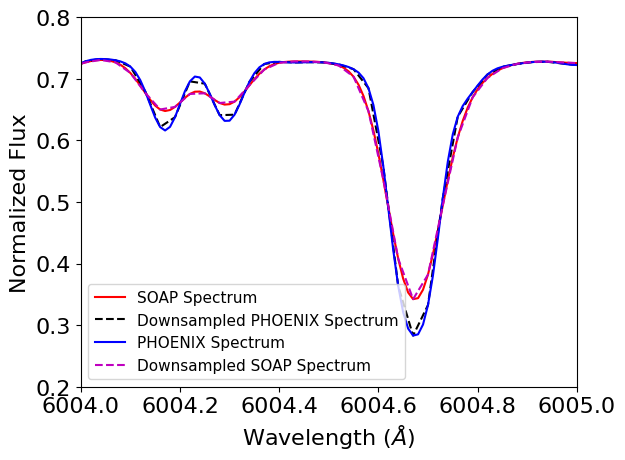

In [29]:
# Compare the SOAP integrated spectrum, the original PHOENIX spectrum,
# and the downsampled PHOENIX spectrum in the same wavelength window.
plt.plot(wave_soap, flux_soap[0], 'r', label='SOAP Spectrum')
plt.plot(downsample_phoenix_wave, downsample_phoenix_flux, 'k--', label='Downsampled PHOENIX Spectrum')
plt.plot(wave_phoenix, flux_phoenix, 'b-', label='PHOENIX Spectrum')
plt.plot(downsample_soap_wave, downsample_soap_flux, 'm--', label='Downsampled SOAP Spectrum')
#plt.xlim(5903.6, 5904.3); plt.ylim(0.3,0.8)
plt.ylim(0.2,0.8); plt.xlim(6004., 6005)
plt.xlabel("Wavelength ("+r"$\AA$"+")")
plt.ylabel("Normalized Flux");
plt.legend(fontsize = 11)

### Do not downlample! Will work with SOAP spectrum

In [30]:
# Export the SOAP, PHOENIX, and their downsampled spectra as ARVE-ready CSV files.
# Each file contains the columns: wave_val, flux_val, and flux_err.
csv_input_dir = Path("./saved_spectra/csv_spectra")
csv_input_dir.mkdir(parents=True, exist_ok=True)

def save_csv_spectra(path, wave, flux, flux_err=0.001):
    flux_array = np.asarray(flux)
    err_array = np.full(flux_array.shape, flux_err, dtype=float)
    spectrum_df = pd.DataFrame({
        "wave_val": np.asarray(wave),
        "flux_val": flux_array,
        "flux_err": err_array,
    })
    spectrum_df.to_csv(path, index=False)

save_csv_spectra(csv_input_dir / "soap.csv", wave_soap, flux_soap[0])
#save_csv_spectra(csv_input_dir / "phoenix.csv", wave_phoenix, flux_phoenix)
#save_csv_spectra(csv_input_dir / "soap_downsampled.csv", downsample_soap_wave, downsample_soap_flux)
#save_csv_spectra(csv_input_dir / "phoenix_downsampled.csv", downsample_phoenix_wave, downsample_phoenix_flux)

print(sorted(path.name for path in csv_input_dir.glob("*.csv")))


['soap.csv']


In [43]:
# Generate random RV shifts, shift only the wavelength grid, compute the CCF,
# and return one DataFrame whose columns contain the returned ccf_vrad arrays.
from pathlib import Path
from tempfile import TemporaryDirectory
import numpy as np
import pandas as pd

def build_random_ccf_vrad_csv(
    input_csv,
    mask_csv,
    output_csv=None,
    *,
    n_samples=2,
    rv_range_ms=(0.0, 100.0),
    vrad_grid=(-15.0, 15.0, 0.1),
    random_seed=42,
    fill_value=1.0,
):
    input_csv = Path(input_csv)
    mask_csv = Path(mask_csv)
    if output_csv is not None:
        output_csv = Path(output_csv)
        output_csv.parent.mkdir(parents=True, exist_ok=True)

    rng = np.random.default_rng(random_seed)
    sampled_rv_ms = rng.uniform(rv_range_ms[0], rv_range_ms[1], size=n_samples)

    ccf_vrad_columns = {}
    summary_rows = []

    with TemporaryDirectory() as tmpdir:
        tmpdir = Path(tmpdir)

        for i, rv_ms in enumerate(sampled_rv_ms):
            rv_kms = rv_ms / 1000.0
            shifted_csv = tmpdir / f"{input_csv.stem}_rv_{i:03d}_{rv_ms:+.3f}ms.csv"

            shift_spectrum_csv(
                input_csv=input_csv,
                output_csv=shifted_csv,
                rv=rv_kms,
                fill_value=fill_value,
            )

            arve_result = create_arve_ccf(
                input_spectrum=shifted_csv,
                mask_path=mask_csv,
                vrad_grid=vrad_grid,
            )

            column_name = f"rv_shift_{rv_ms:+.3f}_ms"
            ccf_vrad_columns[column_name] = np.asarray(arve_result["ccf_vrad"], dtype=float).ravel()

            summary_rows.append(
                {
                    "column_name": column_name,
                    "sampled_rv_ms": rv_ms,
                }
            )

    ccf_vrad_df = pd.DataFrame(ccf_vrad_columns)
    if output_csv is not None:
        ccf_vrad_df.to_csv(output_csv, index=False)

    summary_df = pd.DataFrame(summary_rows)
    return ccf_vrad_df, summary_df

random_ccf_vrad_df, random_rv_summary_df = build_random_ccf_vrad_csv(
    input_csv="./saved_spectra/csv_spectra/soap.csv",
    mask_csv="./saved_spectra/G2_mask.csv",
    output_csv=None,
    n_samples=1,
    rv_range_ms=(0.0, 100.0),
    vrad_grid=(-15.0, 15.0, 0.1),
    random_seed=42,
)

random_rv_summary_df


Extracting CCF RVs.
~~~~ Processed spectra:


100%|██████████| 1/1 [00:00<00:00,  4.01it/s]


,column_name,sampled_rv_ms
0,rv_shift_+77.396_ms,77.395605


Extracting CCF RVs.
~~~~ Processed spectra:


100%|██████████| 1/1 [00:00<00:00,  5.66it/s]


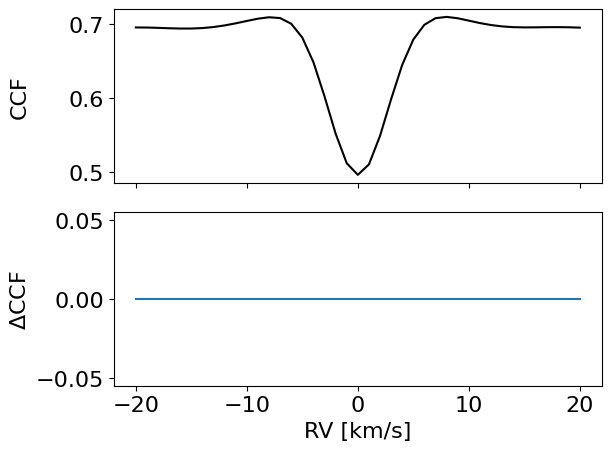

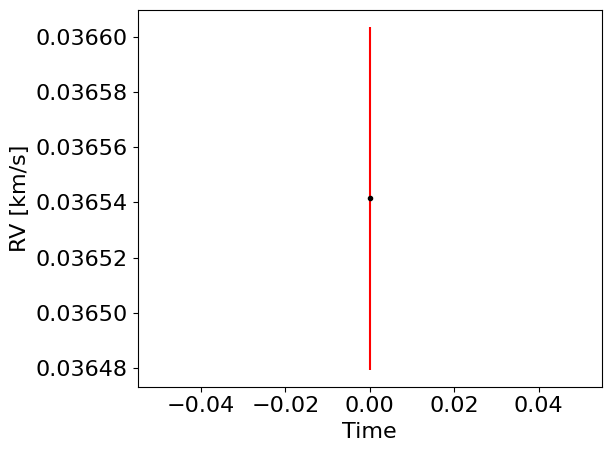

In [41]:
# Example: compute one CCF from one input spectrum and one mask.
soap_arve_result = create_arve_ccf(
    input_spectrum="./saved_spectra/csv_spectra/soap.csv",
    mask_path="./saved_spectra/G5_mask.csv",
    vrad_grid=(-20.0, 20.0, 1),
)

ccf_soap = soap_arve_result["example"]
ccf_vrad_soap = soap_arve_result["ccf_vrad"]
ccf_val_soap = soap_arve_result["ccf_val"]
ccf_err_soap = soap_arve_result["ccf_err"]
time_val_soap = soap_arve_result["time_val"]
vrad_val_soap = soap_arve_result["vrad_val"]
vrad_err_soap = soap_arve_result["vrad_err"]
Nfile = len(soap_arve_result["files"])

# Plot the CCF and RV results for the selected input spectrum.
fig, axs = plt.subplots(2, sharex=True)
axs[0].plot(ccf_vrad_soap, np.median(ccf_val_soap, axis=0), "-k")
axs[0].set_ylabel("CCF")
for i in range(Nfile):
    axs[1].plot(ccf_vrad_soap, ccf_val_soap[i] - np.median(ccf_val_soap, axis=0), "-")
axs[1].set_xlabel("RV [km/s]")
axs[1].set_ylabel("$\Delta$CCF")
fig.align_ylabels()
plt.tight_layout()
plt.show()

plt.figure()
plt.errorbar(time_val_soap, vrad_val_soap, vrad_err_soap, fmt=".", color="k", ecolor="r")
plt.xlabel("Time")
plt.ylabel("RV [km/s]")
plt.tight_layout()
plt.show()

In [39]:
# Example: compute one CCF from one input spectrum and one mask.
phoenix_arve_result = create_arve_ccf(
    input_spectrum="./saved_spectra/csv_spectra/phoenix.csv",
    mask_path="./saved_spectra/G5_mask.csv",
)

ccf_phoenix = phoenix_arve_result["example"]
ccf_vrad_phoenix = phoenix_arve_result["ccf_vrad"]
ccf_val_phoenix = phoenix_arve_result["ccf_val"]
ccf_err_phoenix = phoenix_arve_result["ccf_err"]
time_val_phoenix = phoenix_arve_result["time_val"]
vrad_val_phoenix = phoenix_arve_result["vrad_val"]
vrad_err_phoenix = phoenix_arve_result["vrad_err"]
Nfile = len(phoenix_arve_result["files"])

# Plot the CCF and RV results for the selected input spectrum.
fig, axs = plt.subplots(2, sharex=True)
axs[0].plot(ccf_vrad_phoenix, np.median(ccf_val_phoenix, axis=0), "-k")
axs[0].set_ylabel("CCF")
for i in range(Nfile):
    axs[1].plot(ccf_vrad_phoenix, ccf_val_phoenix[i] - np.median(ccf_val_phoenix, axis=0), "-")
axs[1].set_xlabel("RV [km/s]")
axs[1].set_ylabel("$\Delta$CCF")
fig.align_ylabels()
plt.tight_layout()
plt.show()

plt.figure()
plt.errorbar(time_val_phoenix, vrad_val_phoenix, vrad_err_phoenix, fmt=".", color="k", ecolor="r")
plt.xlabel("Time")
plt.ylabel("RV [km/s]")
plt.tight_layout()
plt.show()

FileNotFoundError: Input spectrum file not found: saved_spectra/csv_spectra/phoenix.csv